# CAPSTONE PROJECT OF GOOGLE ADVANCE DATA ANALYTICS

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### HR dataset

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

### Import packages

In [29]:
# Import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.metrics as metrics
from sklearn.model_selection import GridSearchCV, train_test_split

from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
# Load Dataset

df0 = pd.read_csv("HR_capstone_dataset.csv")
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## EDA and Data Cleaning

In [31]:
# Basic information about the data

df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Basic information and null-duplicates check

In [32]:
# Basic information about the data

df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [33]:
# Check for missing values

df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [34]:
# Check for duplicates

df0.duplicated().sum()

3008

In [35]:
# Duplicates rows are correct or error in the dataset?

df0[df0.duplicated() == True].head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [36]:
# Every response in the survey identical 
# Duplicates are error so drop it

df1 = df0.drop_duplicates(keep='first')
df1.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


### Check outliers in the column of interest

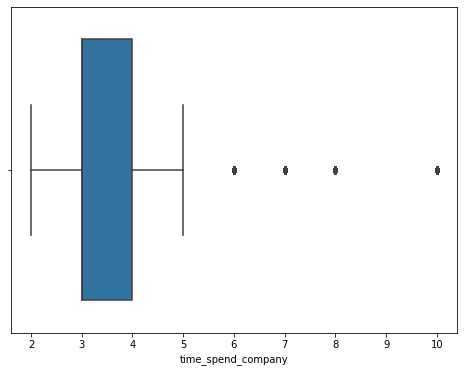

In [37]:
# Check outliers in the columns of interest

plt.figure(figsize = (8,6))
sns.boxplot(df1['time_spend_company'])
plt.show()

In [38]:
# Number of rows containing outliers
Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)

iqr = Q3 - Q1

Ulim = Q3 + 1.5 * iqr
Llim = Q1 - 1.5 * iqr

outlier = df1[(df1['time_spend_company'] > Ulim) | (df1['time_spend_company'] < Llim)]
outlier.shape

(824, 10)

Some model is unbothered from the outlier someother not, so when building the model we have to handle it

## More EDA

In [39]:
# Numbers of people who left vs. stayed
print(df1['left'].value_counts())

# Percentages of people who left vs. stayed
print(df1['left'].value_counts(normalize = True))


0    10000
1     1991
Name: left, dtype: int64
0    0.833959
1    0.166041
Name: left, dtype: float64


# First data Visualization

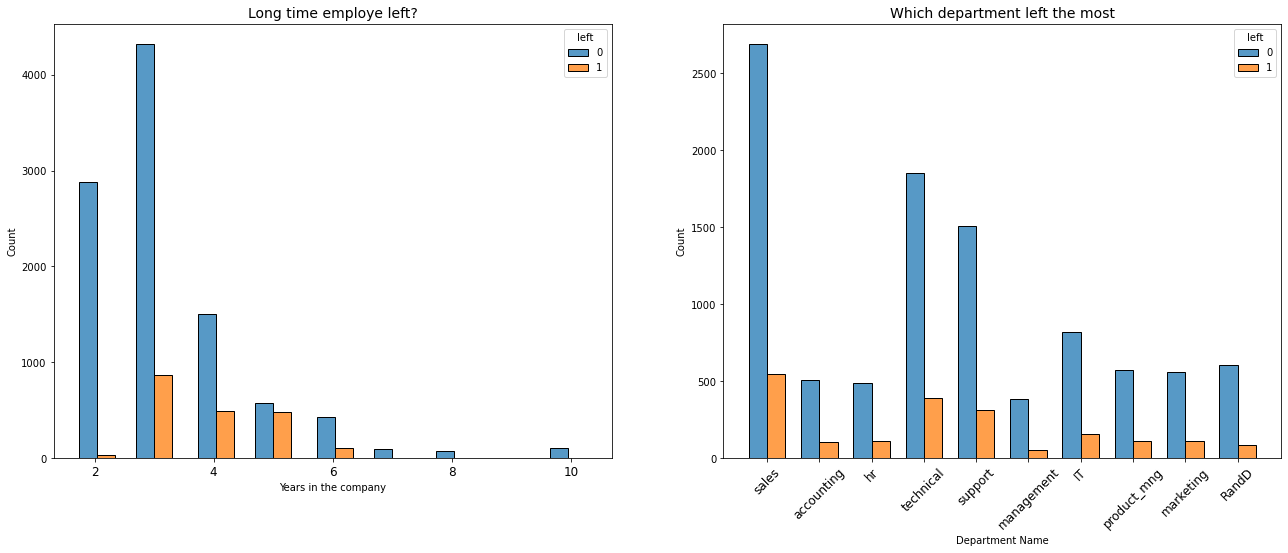

In [41]:
#                                              HIGH LEVEL INTRODUCING VISUALIZATION

# Long time employee and department vs who left

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (22,8))
sns.histplot(data = df1, x = 'time_spend_company', hue = 'left', multiple='dodge',shrink=7, ax=ax1)
ax1.set_title('Long time employe left?', fontsize = 14)
ax1.set(xlabel = 'Years in the company')
ax1.tick_params(axis='x', labelsize=12)

sns.histplot(data = df1, x = 'Department', hue = 'left', multiple='dodge',shrink=0.7, ax=ax2)
ax2.set_title('Which department left the most', fontsize = 14)
ax2.set(xlabel = 'Department Name')
ax2.tick_params(axis='x', labelrotation=45, labelsize=12)
fig.show()

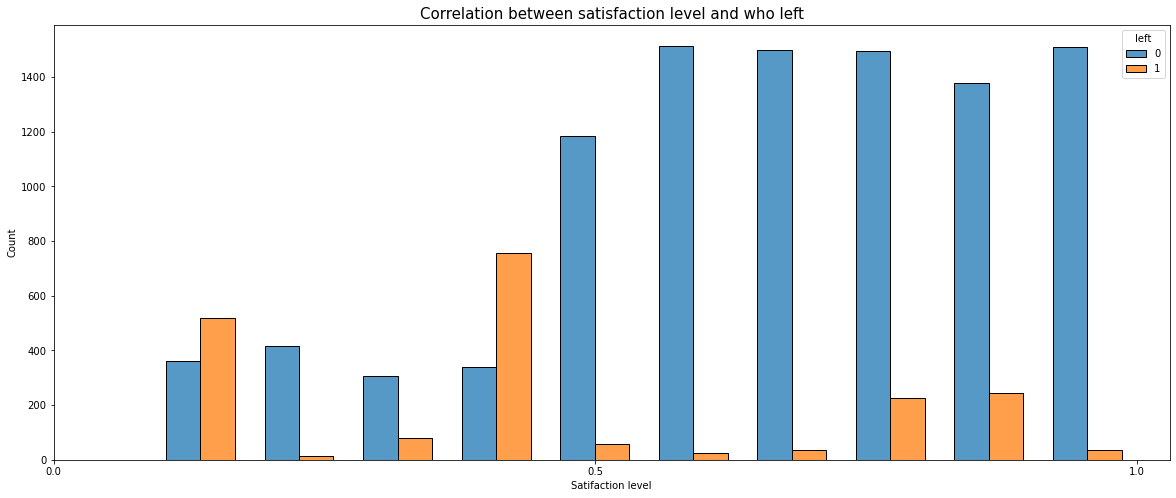

In [42]:
# Satisfaction level is important?

plt.figure(figsize = (20,8))
sns.histplot(data = df1, hue = 'left', x = 'satisfaction_level', multiple = 'dodge', bins = 10, shrink = 0.7)
plt.title('Correlation between satisfaction level and who left', fontsize = 15)
plt.xlabel('Satifaction level')
plt.xticks([0, 0.5, 1])
plt.show()

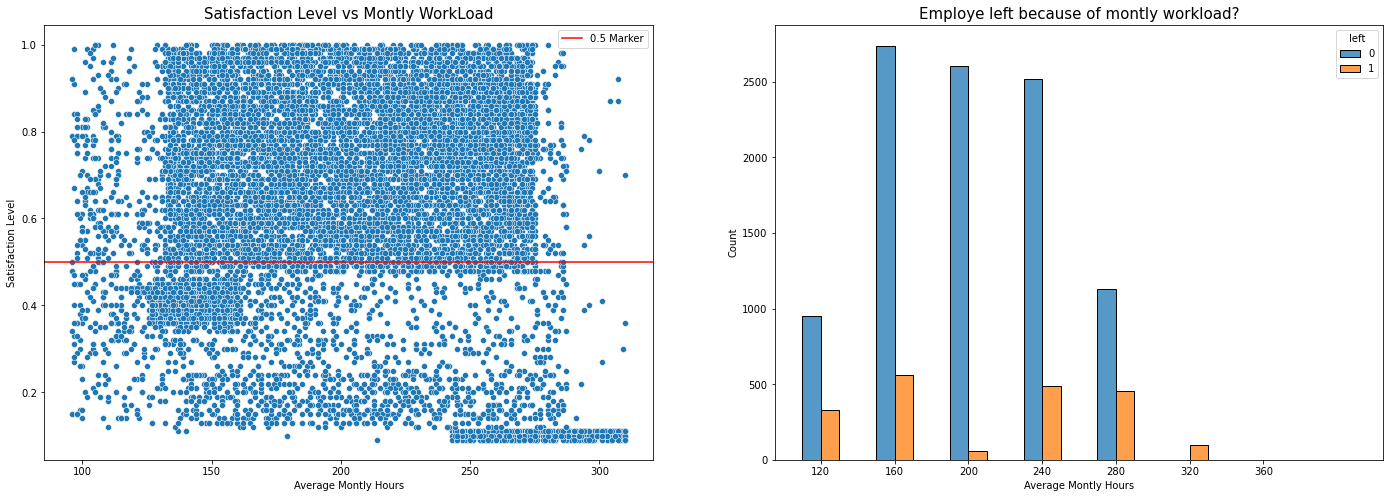

In [43]:
# How much impact have the montly workload on employees satisfation and who left the company?

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (24,8))
sns.scatterplot(data = df1, y = 'satisfaction_level', x = 'average_montly_hours', ax=ax1)
ax1.axhline(0.5, color = 'r', label = '0.5 Marker')
ax1.legend(loc = 'upper right')
ax1.set_title('Satisfaction Level vs Montly WorkLoad', fontsize = 15)
ax1.set(xlabel = 'Average Montly Hours', ylabel = 'Satisfaction Level')

sns.histplot(x = df1['average_montly_hours'], hue = df1['left'], ax = ax2, multiple = 'dodge', binwidth = 40, shrink = 0.5, binrange=(100, 400), kde=False)
ax2.set_xticks(np.arange(120, 400, 40))
ax2.set_title('Employe left because of montly workload?', fontsize = 15)
ax2.set(xlabel = 'Average Montly Hours')
fig.show()

In [44]:
# Some important aspect of the workload

df1[df1['average_montly_hours'] > 280]['left'].value_counts(normalize = True)

1    0.723032
0    0.276968
Name: left, dtype: float64

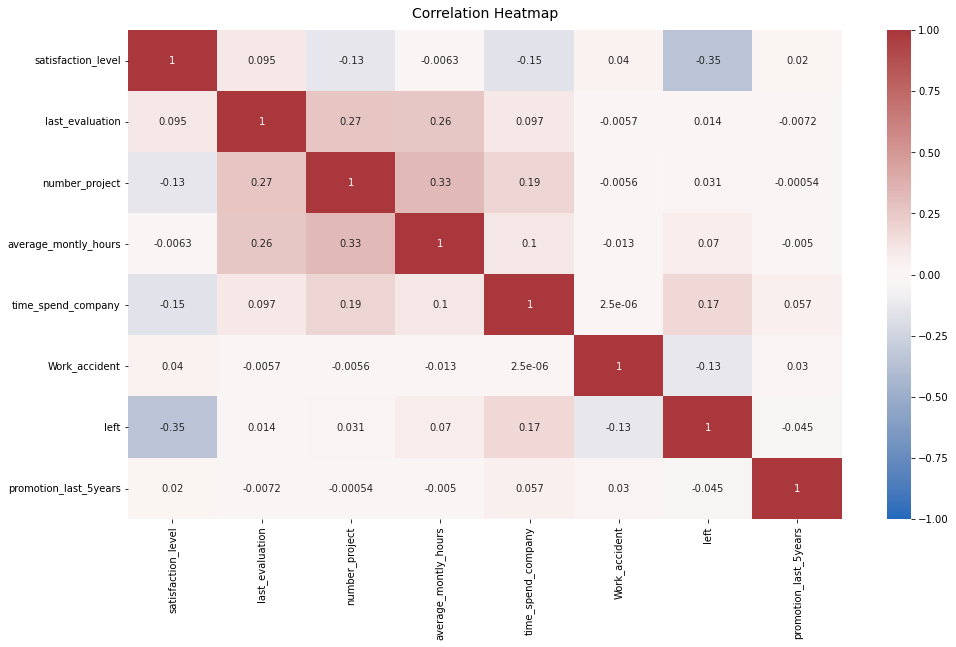

In [45]:
# Correlation Matrix

plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df1.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

## First Model - Logistic Regression

In [46]:
# Organize the building of the model

df1.sample(15)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
3962,0.64,0.50,6,254,6,0,0,0,RandD,medium
10688,0.76,0.74,4,261,3,0,0,0,technical,medium
11599,0.64,0.67,2,223,3,0,0,0,product_mng,medium
1928,0.10,0.97,6,280,4,0,1,0,sales,low
2213,0.65,0.93,4,270,2,0,0,0,sales,medium
3457,0.94,0.59,6,212,2,0,0,0,sales,medium
1932,0.40,0.47,2,128,3,0,1,0,sales,medium
136,0.10,0.84,6,283,4,1,1,0,technical,low
2845,0.73,0.66,3,135,2,0,0,0,sales,medium
9775,0.94,0.87,4,157,3,0,0,0,technical,medium


In [47]:
# Encode categorical variable

df_log = df1

df_log['Salary'] = 0
df_log.loc[df_log['salary'] == 'medium', 'Salary'] = 1
df_log.loc[df_log['salary'] == 'high', 'Salary'] = 2

df_log = df_log.drop(columns='salary')

df_log.sample(15)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,Salary
9911,0.96,0.58,5,197,4,1,0,0,IT,0
6708,0.79,0.97,6,113,2,1,0,0,product_mng,1
3804,0.74,0.57,4,172,3,0,0,0,product_mng,2
2959,0.55,0.82,2,197,4,0,0,0,technical,0
5395,0.83,0.50,4,259,2,0,0,0,support,1
11507,0.93,0.74,5,248,8,1,0,0,support,0
6691,0.14,0.72,4,254,4,0,0,0,support,0
4667,0.62,0.87,6,169,2,1,0,0,sales,1
7498,0.97,0.94,3,202,2,0,0,0,sales,1
4138,0.58,0.43,6,132,3,0,0,0,sales,0


In [48]:
df_log = pd.get_dummies(df_log, drop_first = True)
df_log.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
7795,0.83,0.64,5,272,2,0,0,0,1,0,0,0,0,0,0,1,0,0
893,0.85,0.85,5,267,5,0,1,0,1,0,0,0,0,0,0,0,1,0
4900,0.83,0.87,5,233,3,0,0,0,0,0,0,0,0,0,0,1,0,0
1752,0.10,0.95,6,264,5,0,1,0,1,1,0,0,0,0,0,0,0,0
9235,0.99,0.81,4,229,2,1,0,0,1,0,0,0,0,0,0,1,0,0
397,0.09,0.79,6,293,5,0,1,0,0,0,0,0,0,0,0,1,0,0
7483,0.98,0.89,3,150,3,0,0,0,2,0,0,0,0,0,0,0,1,0
4154,0.98,0.66,3,150,3,0,0,0,1,0,0,1,0,0,0,0,0,0
6412,0.23,0.77,4,140,5,0,0,0,1,0,1,0,0,0,0,0,0,0
10955,0.83,0.99,5,132,3,0,0,0,0,0,0,0,0,0,0,0,0,1


In [49]:
# Outliers have an impact on the Logistic regression model.
# Subset the dataset in the data between the upper and lower threshold
Q1 = df_log['time_spend_company'].quantile(0.25)
Q3 = df_log['time_spend_company'].quantile(0.75)
iqr = Q3 - Q1
ULim = Q3 + 1.5* iqr
Llim = Q1 - 1.5 * iqr

df1_log = df_log[(df_log['time_spend_company'] <= Ulim) & (df_log['time_spend_company'] >= Llim)]

0    0.831468
1    0.168532
Name: left, dtype: float64

In [ ]:
# split the data in the target variable and in the feature

y = df1_log['left']
x = df1_log.drop(columns = 'left')
y.value_counts(normalize = True) # check for imbalance

In [50]:
# split in train and in test data
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, test_size = 0.25, random_state = 42)

In [51]:
# Build, fit and predict

log_clf = LogisticRegression(random_state=42, max_iter=500).fit(x_train, y_train)

y_pred = log_clf.predict(x_test)

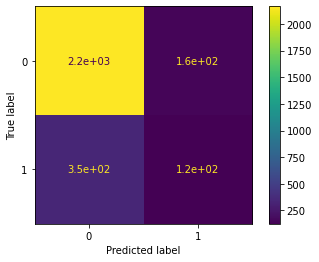

In [52]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_pred, labels = log_clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = log_clf.classes_)
disp.plot();

In [53]:
# Classification report
target_names = ['Predicted would not leave', 'Predicted would leave']
print(metrics.classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.93      0.90      2321
    Predicted would leave       0.44      0.26      0.33       471

                 accuracy                           0.82      2792
                macro avg       0.65      0.60      0.61      2792
             weighted avg       0.79      0.82      0.80      2792



In [65]:
# Score of the model

table = {'recall' : metrics.recall_score(y_test, y_pred),
                    'precision' : metrics.precision_score(y_test, y_pred),
                    'accuracy' : metrics.accuracy_score(y_test, y_pred),
                    'f1' : metrics.f1_score(y_test, y_pred)}

table_df = pd.DataFrame(table, index = [0])

table_df

,recall,precision,accuracy,f1
0,0.26327,0.444444,0.820201,0.330667



**Accuracy** is great. 
The other score not, so probabily is better to use another model

# Second Model - Random Forest

In this case the random forest handle weel the outlier, so there is no need of subset the data

In [67]:
# Set
rf = RandomForestClassifier(random_state = 42)

# Hyperparameters
cv_params = {'max_depth': [3,7, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0, 1.4],
             'min_samples_leaf': [1,2,3,4],
             'min_samples_split': [2,3,4, 5],
             'n_estimators': [100, 300, 500],
             }  

# Scoring Metrics
scoring = {'accuracy', 'precision', 'recall', 'f1'}

# Start the GridSearch over the hyperparameter

rf_cv = GridSearchCV(rf, cv_params, scoring = scoring, cv=5, refit='f1')

# Set target and feature using the outlier

y = df1_log['left']
x = df1_log.drop(columns = 'left')
y.value_counts(normalize = True)

y = df_log['left']
x = df_log.drop(columns = 'left')

# Split in train, validation and test data

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, test_size = 0.25, random_state = 42)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 42)

In [68]:
%%time

# Fit
rf_cv.fit(x_tr, y_tr)

GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=42,
                                  

In [69]:
# Check the best parameter
rf_cv.best_score_ , rf_cv.best_params_

(0.9458408647491195,
 {'max_depth': None,
  'max_features': 1.0,
  'max_samples': 0.7,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 300})

In [74]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc
  
    Returns a pandas df with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.  
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                        })
  
    return table

rf_cv_results = make_results('RandomForestCV Train', rf_cv, 'f1')
rf_cv_results

,model,precision,recall,f1,accuracy
0,RandomForestCV Train,0.979823,0.914644,0.945841,0.982948


In [75]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In: 
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)

    accuracy = metrics.accuracy_score(y_test_data, preds)
    precision = metrics.precision_score(y_test_data, preds)
    recall = metrics.recall_score(y_test_data, preds)
    f1 = metrics.f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                         })
  
    return table

rf_val_scores = get_scores('Random Forest Validation', rf_cv, x_val, y_val)
result = pd.concat([rf_cv_results, rf_val_scores])

rf_test_scores = get_scores('Random Forest Test', rf_cv, x_test, y_test)
result = pd.concat([rf_cv_results, rf_val_scores, rf_test_scores])

# Result over the Validation and Test dataset
result

,model,precision,recall,f1,accuracy
0,RandomForestCV Train,0.979823,0.914644,0.945841,0.982948
0,Random Forest Validation,0.986413,0.926020,0.955263,0.984882
0,Random Forest Validation,0.991435,0.929719,0.959585,0.986991


**The parameter are great, so this model do a much better job**

### Importance among the feature

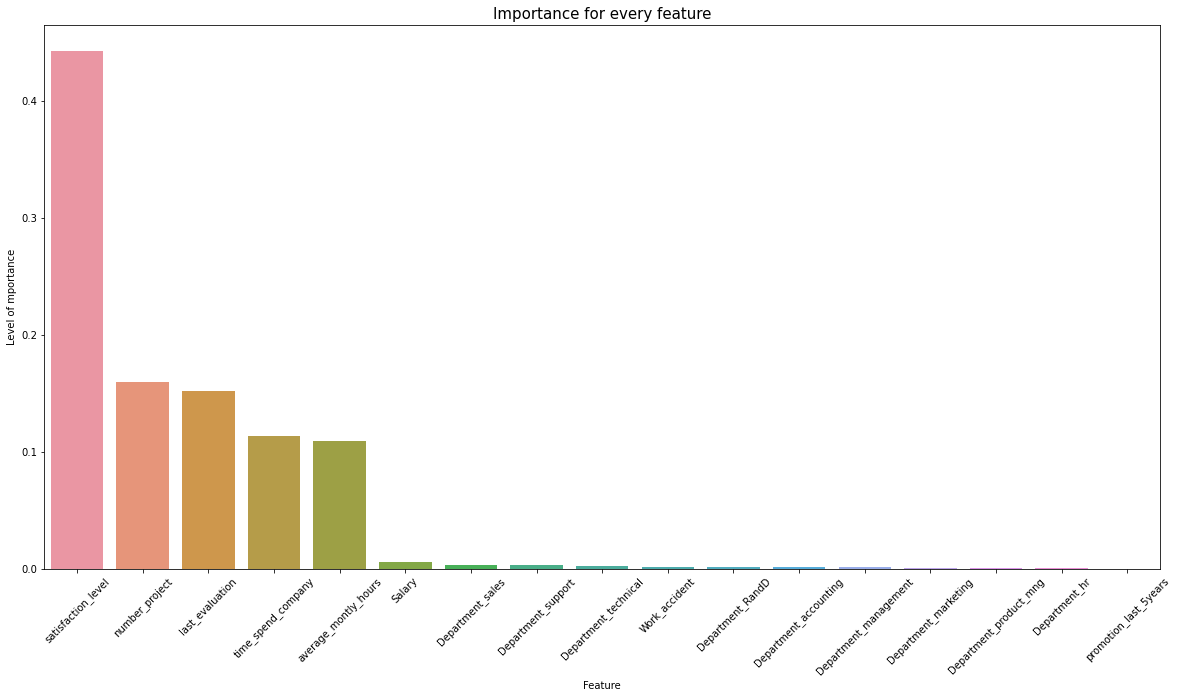

In [121]:
importances = zip(rf_cv.best_estimator_.feature_importances_, x_train.columns) # list of importance and feature name
importances_df = pd.DataFrame(importances) # dataframe
importances_df = importances_df.sort_values(0, ascending = False) # sort in descending order

# Visualize the importance

fig, ax = plt.subplots(figsize = (20,10))
sns.barplot(x = importances_df[1], y = importances_df[0], ax = ax)
ax.set_title('Importance for every feature', fontsize = 15)
ax.set(xlabel = 'Feature', ylabel = 'Level of mportance')
ax.tick_params(axis='x', rotation=45, labelsize = 10, labelright = True)
plt.show()